In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def gamma_k(_kx, _ky):
    return (np.cos(_kx) + np.cos(_ky))/2

def gamma2_k(_kx, _ky, eta = 1.):
    return 1/4 * (np.cos(_kx)**2 + np.cos(_ky)**2 + 2 * np.cos(_kx) * np.cos(_ky) * np.cos(np.pi/2 * (1 - eta)))

def a_func(t, n, delta = 1., lamb = 0., alpha = 1.):
    return 2 * (delta + t - 2 * n * (t/2 + alpha * lamb * delta))

def b_func(t, n, delta = 1., lamb = 0., beta = 1.):
    return 2 * (1 - 2 * n + n**2 + 3/4 * (t)**2 + beta * t * lamb * delta )

def get_bog_pars(t, n, _kx, _ky, delta = 1., lamb = 0., eta = 1., alpha = 1., beta = 1.):
    a = a_func(t, n, delta, lamb, alpha)
    b = b_func(t, n, delta, lamb, beta)

    wk = np.abs(np.sqrt(a**2 - b**2 * gamma2_k(_kx, _ky, eta) + 0j))
    
    return a, b, wk

def t_func(b, wk, gamma2k, N):
    return np.abs(b)/N * np.real(np.sum(np.divide(gamma2k, wk)))

def n_func(a, wk, N):
    return 1/(2*N) * np.sum(np.abs(np.divide(a, wk) - 1))

In [3]:
def get_flow(n0, t0, delta = 1., lamb = 0., eta = 1., alpha = 1., beta = 1., k_bins = 100):
    # strating parameters
    n_old = n0
    t_old = t0

    N = k_bins**2
    k = np.linspace(-np.pi, np.pi, k_bins, endpoint = False)

    px, py = np.meshgrid(k, k, indexing = 'ij')

    # get general parameters
    a, b, wk = get_bog_pars(t_old, n_old, px, py, delta, lamb, eta, alpha, beta)
    gamma2k = gamma2_k(px, py, eta)

    # get new t
    t_new = t_func(b, wk, gamma2k, N)

    # get new n
    n_new = n_func(a, wk, N)

    # get flow
    t_flow = t_new - t_old
    n_flow = n_new - n_old

    return n_flow, t_flow

In [4]:
def get_flow_map(delta = 1., lamb = 0., eta = 1., alpha = 1., beta = 1., n_min = 0., n_max = 1., t_min = 0., t_max = 1., n_bins = 101, t_bins = 101, k_bins = 100, _show_tqdm = True):
    np.seterr(all='ignore')
    ns = np.linspace(n_min, n_max, n_bins)
    ts = np.linspace(t_min, t_max, t_bins)

    flow_map = np.zeros((len(ts), len(ns)))

    arrows_dirs = []
    arrows_mags = []
    arrows_positions = []

    for i_n, n in tqdm(enumerate(ns), total = len(ns), disable = not _show_tqdm):
        for it, t in enumerate(ts):
            n_flow, t_flow = get_flow(n, t, delta, lamb, eta, alpha = alpha, beta = beta, k_bins = k_bins)
            flow_map[it, i_n] = np.atan2(t_flow, n_flow)

            if np.abs(n_flow) > 999. or np.abs(t_flow) > 999.:
                continue

            arrows_positions.append((t, n))
            arrows_mags.append(n_flow**2 + t_flow**2)
            arrows_dirs.append(np.atan2(t_flow, n_flow))
    
    normalized_arrow_mags = arrows_mags / np.max(arrows_mags)

    return flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts

In [5]:
def plot_arrow_map(arrows_positions, normalized_arrow_mags, arrows_dirs):
    for pos, mag, dir in zip(arrows_positions, normalized_arrow_mags, arrows_dirs):
        mag *= .1
        y, x = pos
        dx = mag * np.cos(dir)
        dy = mag * np.sin(dir)
        plt.arrow(x - dx/2, y - dy/2, dx, dy, length_includes_head=True, width = .001*mag, head_width = .1 * mag, head_length=.4 * mag, fc = 'black')
    plt.ylabel('t')
    plt.xlabel('n')
    #plt.scatter([0.05142], [0.24021], s=50, facecolors = 'none', edgecolors = 'purple')
    plt.show()


In [6]:
def plot_flow_map(map, ns, ts, title = None, additional_points = []):
    # --- Main plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.get_cmap('twilight')  # better than hsv

    if title is not None:
        plt.title(title)
    
    plt.imshow(map, cmap='twilight', aspect = 'auto', extent = (ns[0], ns[-1], ts[0], ts[-1]))
    plt.xlabel('n')
    plt.ylabel('t')

    for point in additional_points:
        plt.scatter([point[0]], [point[1]], s=50, facecolors = 'none', edgecolors = 'y')

    if np.max(ns) > 1. or np.min(ns) < 0. or np.max(ts) > 1. or np.min(ts) < 0.:
        plt.hlines([0., 1.], 0., 1., ls = '--', colors = 'white', alpha = .2)
        plt.vlines([0., 1.], 0., 1., ls = '--', colors = 'white', alpha = .2)

    # --- Create side axis for circular colorbar ---

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="30%", pad=0.4)

    # --- Build circular colorbar ---
    N = 400
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    angle_cb = np.arctan2(-Y, X)
    radius = np.sqrt(X**2 + Y**2)

    mask = radius <= 1

    norm = plt.Normalize(-np.pi, np.pi)
    colors = cmap(norm(angle_cb))
    colors[~mask] = (1, 1, 1, 0)  # transparent outside

    cax.imshow(colors, extent=(-1, 1, -1, 1))
    cax.set_aspect('equal')
    cax.axis('off')
    cax.set_title("Direction")

    plt.show()

100%|██████████| 201/201 [00:08<00:00, 25.05it/s]


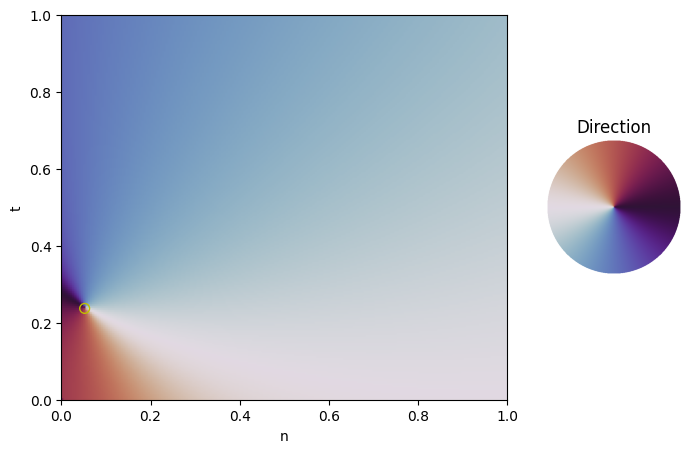

In [368]:
flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(1., 0., n_bins = 201, t_bins = 201)
#plot_arrow_map(arrows_positions, normalized_arrow_mags, arrows_dirs)
plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, additional_points=[(0.05238, 0.23717)])

100%|██████████| 201/201 [00:12<00:00, 15.63it/s]


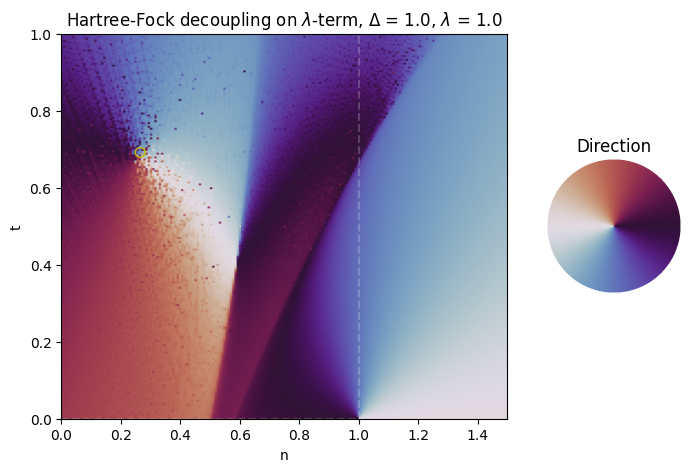

100%|██████████| 201/201 [00:13<00:00, 15.45it/s]


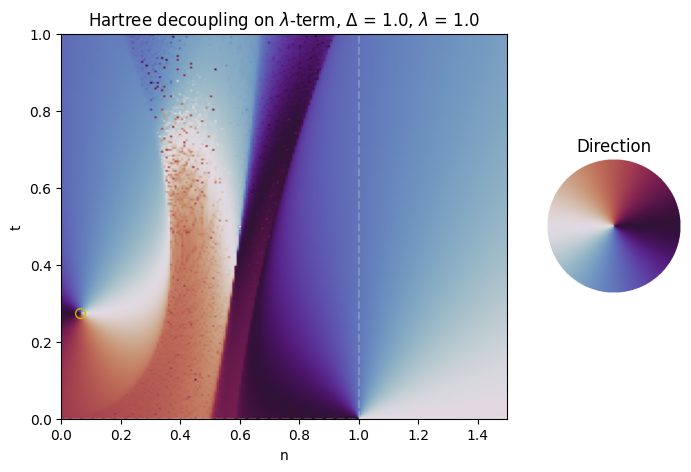

100%|██████████| 201/201 [00:12<00:00, 15.67it/s]


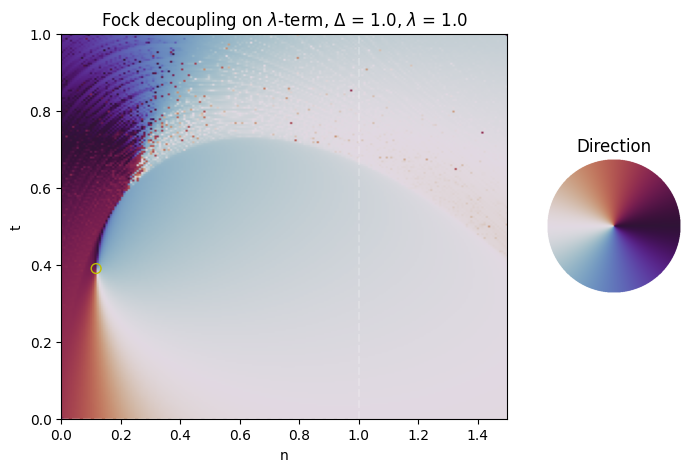

In [364]:
abs = [(1., 1.), (1., 0), (0., 1.)]
titles = ['Hartree-Fock', 'Hartree', 'Fock']
a_points = [
    [(0.26541, 0.69178)],
    [(0.06455, 0.2731)],
    [(0.11719, 0.3901)]
    ]

delta = 1.
lamb = 1.

for ab, title, ap in zip(abs, titles, a_points):
    a, b = ab
    flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, 1., a, b, n_max = 1.5, n_bins = 201, t_bins = 201)
    plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'{title} decoupling on $\lambda$-term, $\Delta$ = {delta}, $\lambda$ = {lamb}',
                  additional_points=ap)

100%|██████████| 101/101 [00:03<00:00, 31.31it/s]


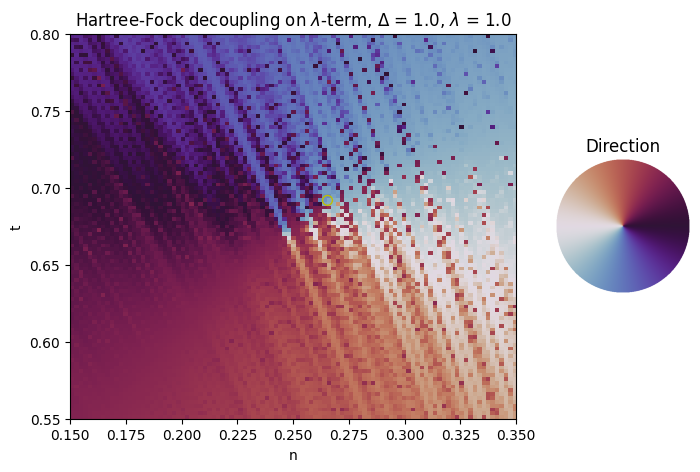

100%|██████████| 101/101 [00:10<00:00,  9.28it/s]


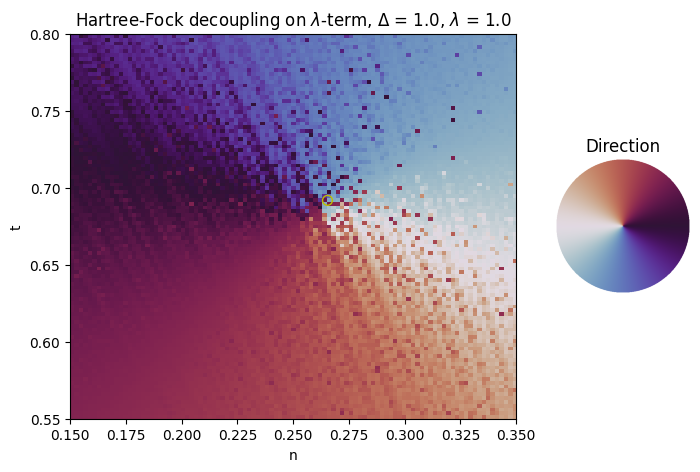

100%|██████████| 101/101 [01:04<00:00,  1.57it/s]


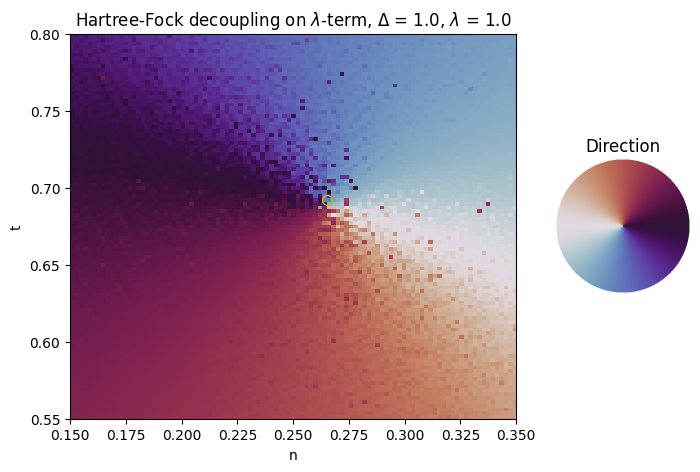

In [ ]:
ap = [(0.26541, 0.69178)]
a = 1.
b = 1.
title = titles[0]
flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, 1., a, b, n_min = .15, n_max = .35, t_min = .55, t_max = .8, 
                                                                                      n_bins = 101, t_bins = 101)
plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'{title} decoupling on $\lambda$-term, $\Delta$ = {delta}, $\lambda$ = {lamb}',
                additional_points=ap)

flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, 1., a, b, n_min = .15, n_max = .35, t_min = .55, t_max = .8, 
                                                                                      n_bins = 101, t_bins = 101, k_bins = 200)
plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'{title} decoupling on $\lambda$-term, $\Delta$ = {delta}, $\lambda$ = {lamb}',
                additional_points=ap)

flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, 1., a, b, n_min = .15, n_max = .35, t_min = .55, t_max = .8, 
                                                                                      n_bins = 101, t_bins = 101, k_bins = 500)
plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'{title} decoupling on $\lambda$-term, $\Delta$ = {delta}, $\lambda$ = {lamb}',
                additional_points=ap)

100%|██████████| 101/101 [04:19<00:00,  2.57s/it]


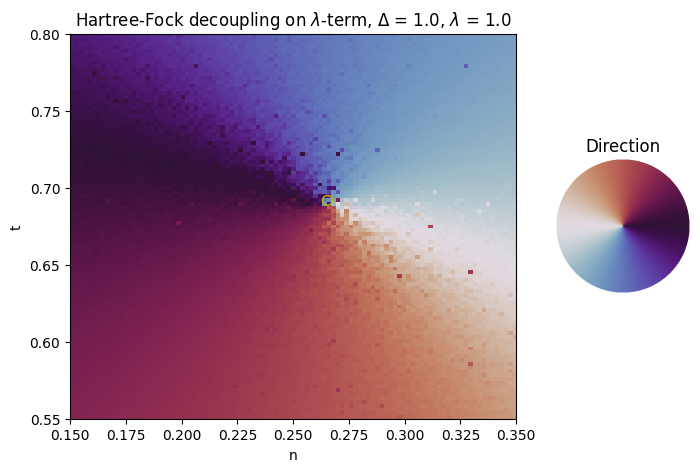

In [ ]:
flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, 1., a, b, n_min = .15, n_max = .35, t_min = .55, t_max = .8, 
                                                                                      n_bins = 101, t_bins = 101, k_bins = 1000)
plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'{title} decoupling on $\lambda$-term, $\Delta$ = {delta}, $\lambda$ = {lamb}',
                additional_points=ap)

100%|██████████| 51/51 [04:47<00:00,  5.64s/it]


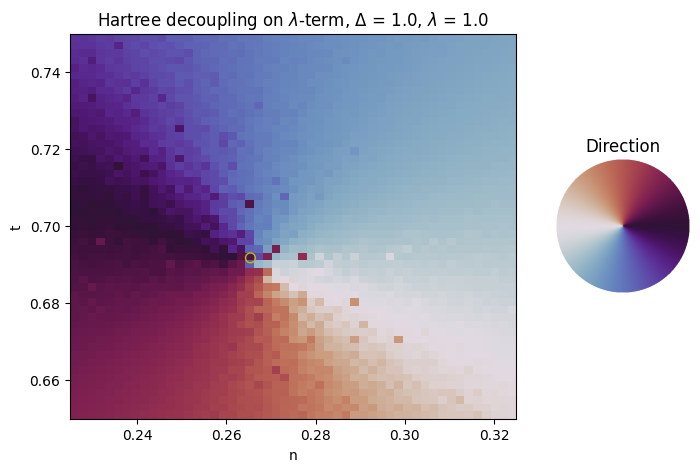

In [381]:
ap = [(0.26541, 0.69178)]
delta, lamb = 1., 1.
a, b = 1., 1.
flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, 1., a, b, n_min = .225, n_max = .325, t_min = .65, t_max = .75, 
                                                                                      n_bins = 51, t_bins = 51, k_bins = 2000)
plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'{title} decoupling on $\lambda$-term, $\Delta$ = {delta}, $\lambda$ = {lamb}',
                additional_points=ap)

100%|██████████| 201/201 [00:12<00:00, 15.79it/s]


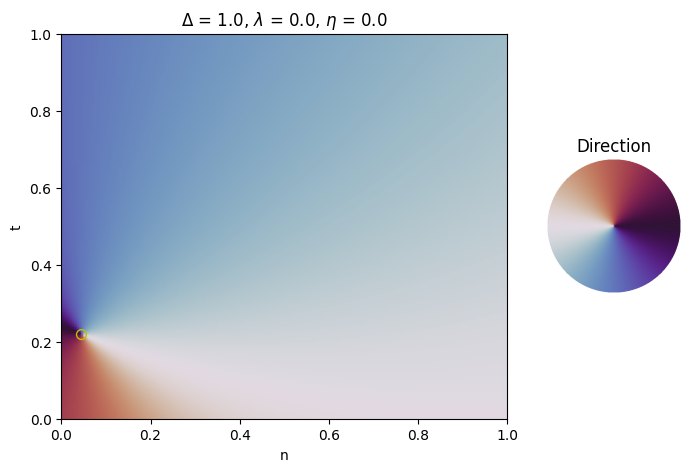

In [365]:
delta = 1.
lamb = 0.
eta = 0.

flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, eta, n_max = 1., n_bins = 201, t_bins = 201)
plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'$\Delta$ = {delta}, $\lambda$ = {lamb}, $\eta$ = {eta}', additional_points=[(0.04519, 0.21858)])

100%|██████████| 301/301 [00:23<00:00, 13.06it/s]


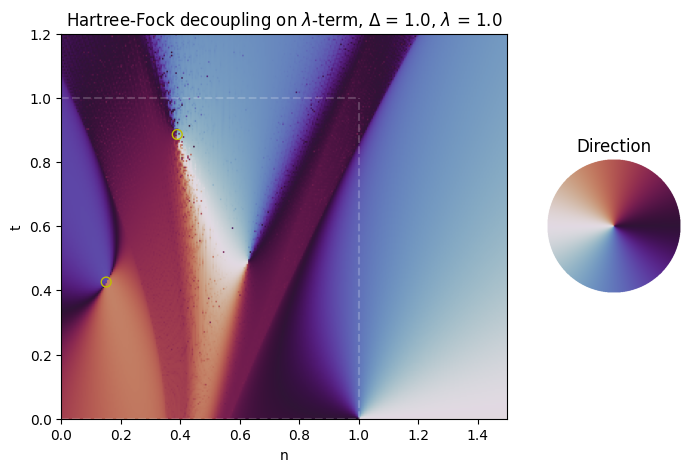

100%|██████████| 301/301 [00:23<00:00, 12.62it/s]


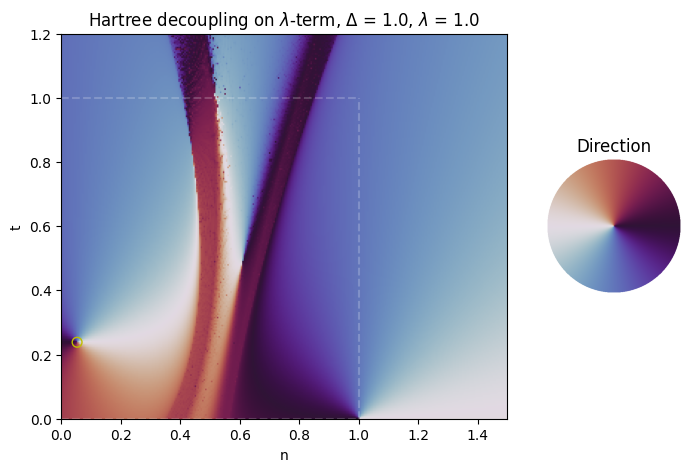

In [382]:
abs = [(1., 1.), (1., 0)]
titles = ['Hartree-Fock', 'Hartree']
a_points = [
    [(0.151, 0.426), (0.38992, 0.886)],
    [(0.05321, 0.23833)]
    ]

delta = 1.
lamb = 1.

for ab, title, ap in zip(abs, titles, a_points):
    a, b = ab
    flow_map, arrows_dirs, normalized_arrow_mags, arrows_positions, ns, ts = get_flow_map(delta, lamb, 0., a, b, t_max = 1.2, n_max = 1.5, n_bins = 301, t_bins = 241)
    plot_flow_map(np.flip(flow_map, axis = 0), ns, ts, title = fr'{title} decoupling on $\lambda$-term, $\Delta$ = {delta}, $\lambda$ = {lamb}',
                  additional_points=ap)